In [ ]:
import numpy as np  # массивы, векторы и численные вычисления
import matplotlib.pyplot as plt  # построение графиков
from scipy.signal import windows  # оконные функции для обработки сигналов
from scipy import signal  # инструменты SciPy для анализа и обработки сигналов

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

: 

---
## Задание 1
Свёртка прямоугольного периодического сигнала с двумя ядрами:
- **(а)** Гауссово ядро: `y = A·exp(-x²)`
- **(б)** Линейное ядро: `y = -k·x + b`

Используется встроенная функция `numpy.convolve`.

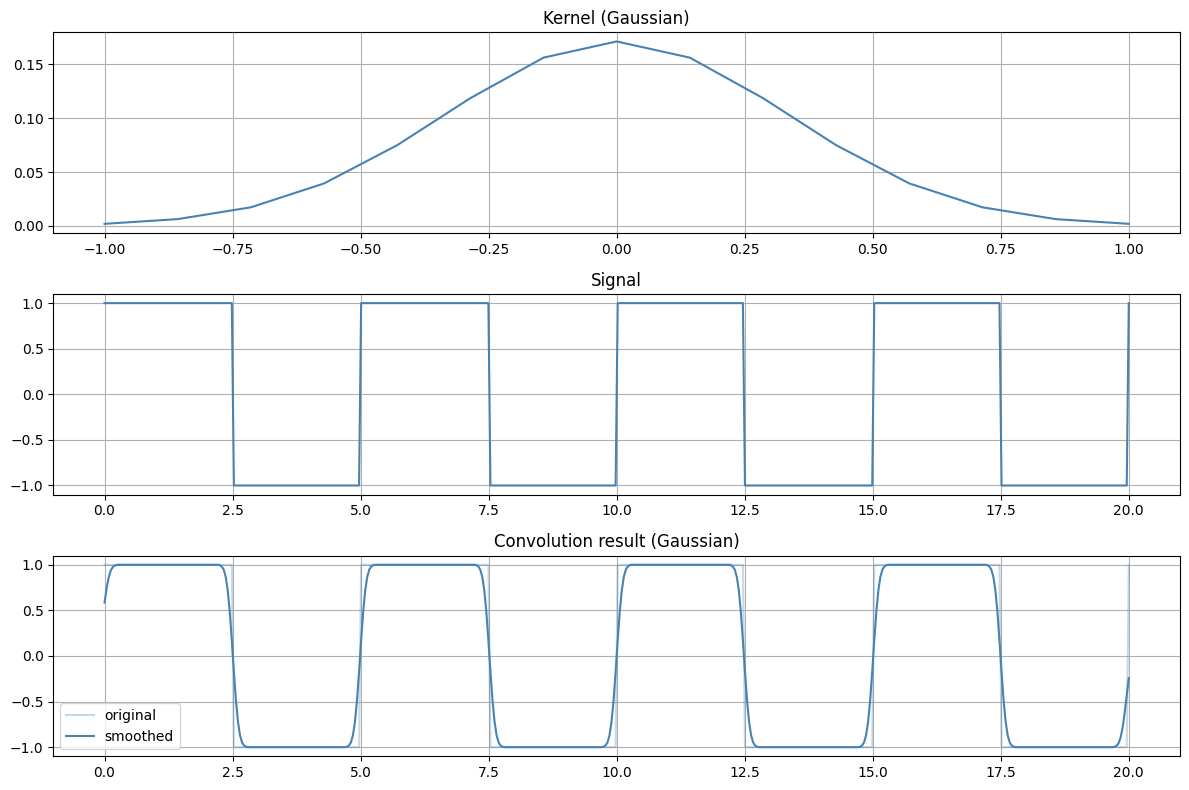

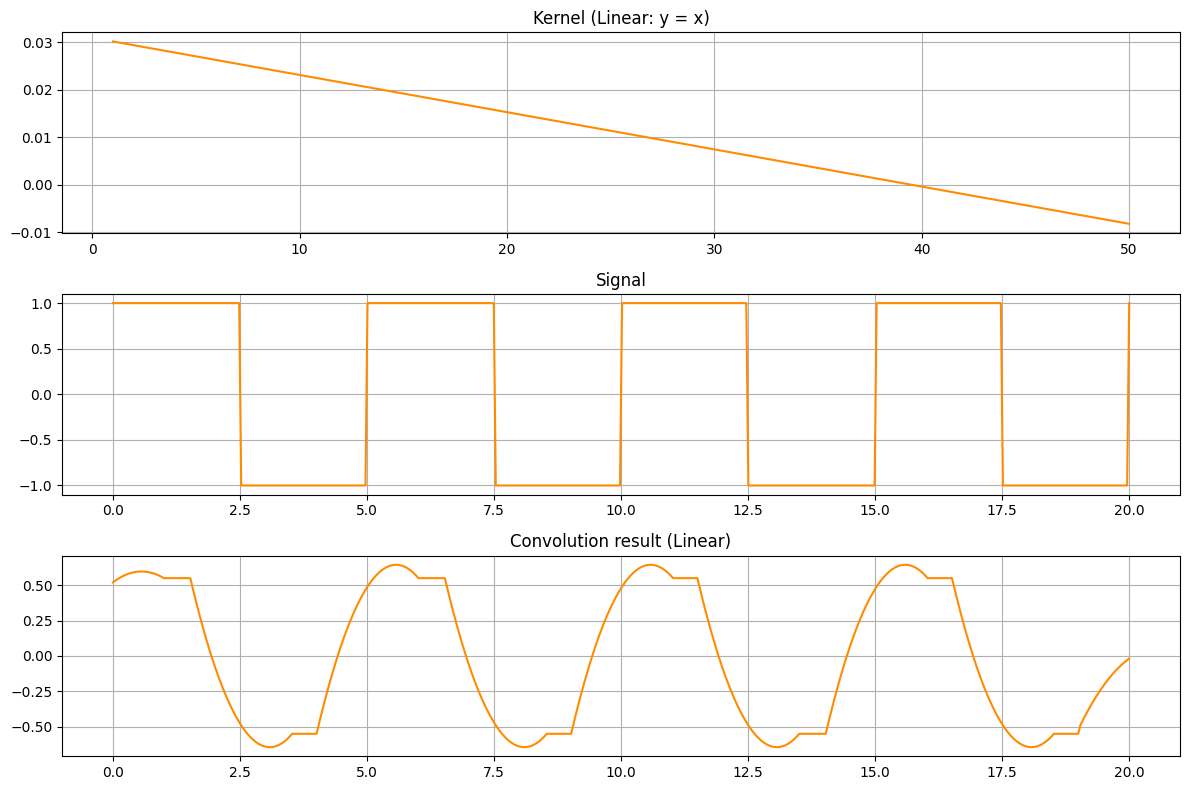

In [64]:
def make_rect_signal(n_points=200, t_max=20.0, period=5.0, duty=0.5, amplitude=1.0):
    """Прямоугольный периодический сигнал на отрезке [0, t_max]."""
    t = np.linspace(0, 20, 500)
    sig = signal.square(2 * np.pi * 0.2 * t)  # частота 0.2 Гц → период 5 сек
    return t, sig

def make_gaussian_kernel(size=15, sigma=0.5):
    """Узкое гауссово ядро для сглаживания: y = exp(-x^2 / (2*sigma^2))."""
    x = np.linspace(-3*sigma, 3*sigma, size)
    kernel = np.exp(-x**2 / (2 * sigma**2))
    return kernel / kernel.sum()

def make_linear_kernel(size=50):
    """Линейное ядро y = x (возрастающее), нормированное."""
    x = np.arange(1, size + 1, dtype=float)
    return (-1 *  x / x.sum()) + 0.031


t, sign = make_rect_signal()
gauss_kernel  = make_gaussian_kernel()
linear_kernel = make_linear_kernel()

conv_gauss  = np.convolve(sign, gauss_kernel,  mode='same')
conv_linear = np.convolve(sign, linear_kernel, mode='same')

# --- plot (а) Гаусс ---
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(np.linspace(-1, 1, len(gauss_kernel)), gauss_kernel, color='steelblue')
axes[0].set_title('Kernel (Gaussian)')
axes[1].plot(t, sign, color='steelblue')
axes[1].set_title('Signal')
axes[2].plot(t, sign, color='steelblue', alpha=0.3, label='original')
axes[2].plot(t, conv_gauss, color='steelblue', label='smoothed')
axes[2].set_title('Convolution result (Gaussian)')
axes[2].legend()
plt.tight_layout()
plt.show()

# --- plot (б) Линейное ---
x_lin = np.arange(1, len(linear_kernel) + 1, dtype=float)
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(x_lin, linear_kernel, color='darkorange')
axes[0].set_title('Kernel (Linear: y = x)')
axes[1].plot(t, sign, color='darkorange')
axes[1].set_title('Signal')
axes[2].plot(t, conv_linear, color='darkorange')
axes[2].set_title('Convolution result (Linear)')
plt.tight_layout()
plt.show()

---
## Задание 2
Реализация **собственного алгоритма свёртки** без использования `numpy.convolve`.

Формула дискретной свёртки:
$$
(f * g)[n] = \sum_{k=0}^{M-1} f[k] \cdot g[n - k]
$$

Результат сравнивается с `numpy.convolve` для верификации.

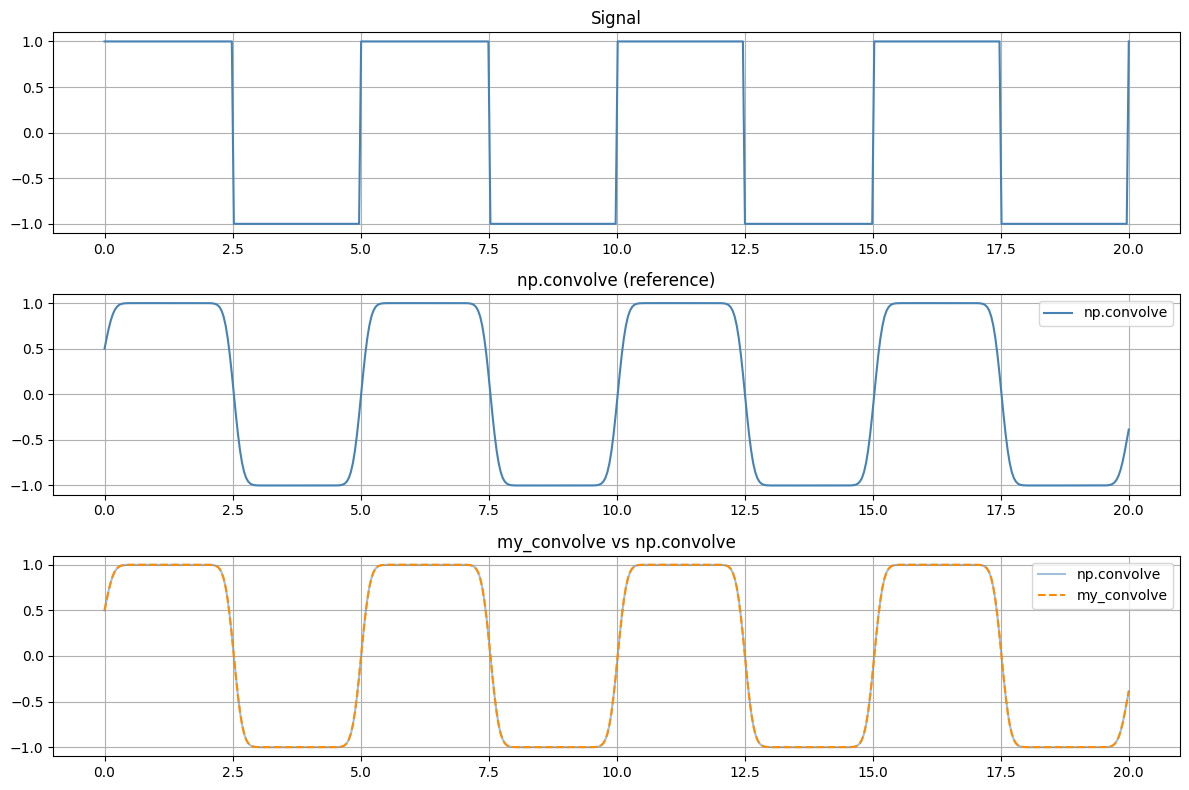

Max difference: 2.22e-16


In [26]:
x_kernel = np.linspace(-5, 5, 50)
kernel_a = np.exp(-x_kernel**2)
kernel_a = kernel_a / np.sum(kernel_a)

def my_convolve(signal, kernel):
    """Дискретная свёртка по определению (f*g)[n] = sum_k f[k]*g[n-k], режим 'same'."""
    n, m = len(signal), len(kernel)
    result = np.zeros(n)
    pad = m // 2
    signal_padded = np.pad(signal, (pad, pad), mode='constant')
    for i in range(n):
        result[i] = np.sum(signal_padded[i:i+m] * kernel)
    return result

ref  = np.convolve(sign, kernel_a[::-1], mode='same')
mine = my_convolve(sign, kernel_a)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t, sign, color='steelblue')
axes[0].set_title('Signal')

axes[1].plot(t, ref, color='steelblue', label='np.convolve')
axes[1].set_title('np.convolve (reference)')
axes[1].legend()

axes[2].plot(t, ref,  color='steelblue', alpha=0.5, label='np.convolve')
axes[2].plot(t, mine, color='darkorange', linestyle='--', label='my_convolve')
axes[2].set_title('my_convolve vs np.convolve')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Max difference: {np.max(np.abs(mine - ref)):.2e}")

## Задание 3
Теорема о свёртке: свёртка во временной области эквивалентна умножению в частотной:

$$\mathcal{F}(f * g) = \mathcal{F}(f) \cdot \mathcal{F}(g)$$

Проверяем: сравниваем результат `np.convolve` с `IFFT(FFT(signal) * FFT(kernel))`.

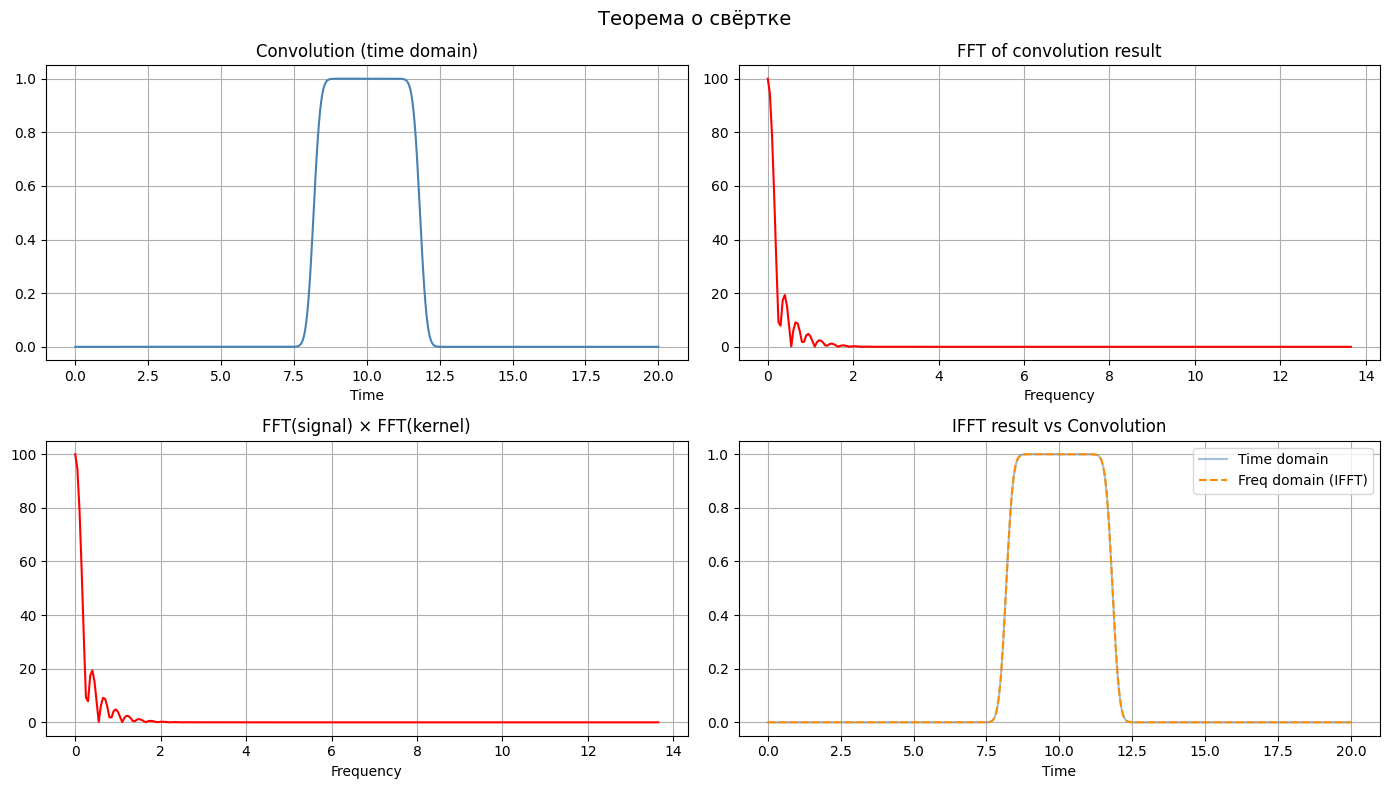

Max difference: 5.55e-16


In [30]:
kernel_a = np.exp(-(x_kernel / 1.5)**2)
kernel_a = kernel_a / np.sum(kernel_a)

# сигнал — одиночный импульс
sig_pulse = np.zeros(500)
sig_pulse[200:300] = 1.0

pad_len = len(sig_pulse) + len(kernel_a) - 1
t_full  = np.linspace(0, 20, pad_len)
freqs   = np.fft.fftfreq(pad_len, d=20/pad_len)
half    = pad_len // 2

# --- верхний путь: time → convolve → FFT ---
conv_time   = np.convolve(sig_pulse, kernel_a, mode='full')
fft_of_conv = np.fft.fft(conv_time)

# --- нижний путь: FFT * FFT → IFFT ---
S            = np.fft.fft(sig_pulse, n=pad_len)
K            = np.fft.fft(kernel_a,  n=pad_len)
freq_product = S * K
conv_freq    = np.fft.ifft(freq_product).real

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Теорема о свёртке', fontsize=14)

# [0,0] свёртка во времени
axes[0, 0].plot(t_full, conv_time, color='steelblue')
axes[0, 0].set_title('Convolution (time domain)')
axes[0, 0].set_xlabel('Time')

# [0,1] FFT от свёртки
axes[0, 1].plot(freqs[:half], np.abs(fft_of_conv)[:half], color='red')
axes[0, 1].set_title('FFT of convolution result')
axes[0, 1].set_xlabel('Frequency')

# [1,0] умножение спектров
axes[1, 0].plot(freqs[:half], np.abs(freq_product)[:half], color='red')
axes[1, 0].set_title('FFT(signal) × FFT(kernel)')
axes[1, 0].set_xlabel('Frequency')

# [1,1] IFFT → сравнение
axes[1, 1].plot(t_full, conv_time, color='steelblue', alpha=0.5, label='Time domain')
axes[1, 1].plot(t_full, conv_freq, color='darkorange', linestyle='--', label='Freq domain (IFFT)')
axes[1, 1].set_title('IFFT result vs Convolution')
axes[1, 1].set_xlabel('Time')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"Max difference: {np.max(np.abs(conv_time - conv_freq)):.2e}")

## Задание 4
Гауссово ядро как сглаживающий фильтр во временной области.

Ядро Гаусса в частотной области (narrowband filter):

$$g = e^{-0.5\left(\frac{h-p}{s}\right)^2}, \quad s = \frac{w(2\pi - 1)}{4\pi}$$

где `p` — центральная частота (Hz), `w` — ширина полосы FWHM (Hz).

Применяем свёртку зашумлённого сигнала с гауссовым ядром во временной области.

C:\Users\toasty\AppData\Local\Temp\ipykernel_14076\2260494737.py:12: RuntimeWarning: divide by zero encountered in divide
  k = np.exp(-0.5 * (x / sigma_points)**2)
C:\Users\toasty\AppData\Local\Temp\ipykernel_14076\2260494737.py:12: RuntimeWarning: invalid value encountered in divide
  k = np.exp(-0.5 * (x / sigma_points)**2)


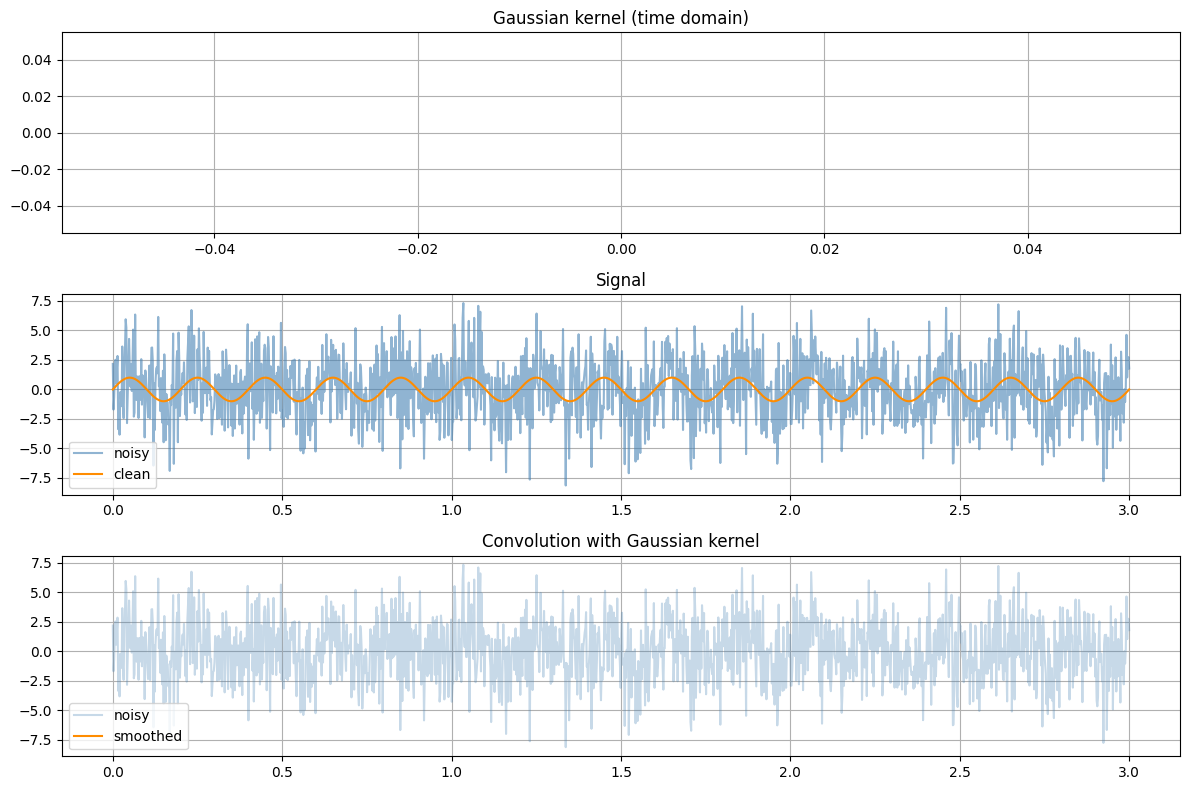

In [61]:
fs     = 500        # частота дискретизации
T      = 3.0        # длительность сигнала
f0     = 5.0        # частота основного сигнала
t4     = np.linspace(0, T, int(fs * T))

clean  = np.sin(2 * np.pi * f0 * t4)
noisy  = clean + 2.5 * np.random.standard_normal(len(t4))

def gaussian_kernel_time(size=201, sigma_points=30):
    """Гауссово ядро во временной области, sigma_points — ширина в сэмплах."""
    x = np.arange(size) - size // 2
    k = np.exp(-0.5 * (x / sigma_points)**2)
    return k / k.sum()

kernel_gauss = gaussian_kernel_time(size=201, sigma_points=0)
smoothed     = np.convolve(noisy, kernel_gauss, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(np.linspace(-3, 3, len(kernel_gauss)), kernel_gauss, color='steelblue')
axes[0].set_title('Gaussian kernel (time domain)')

axes[1].plot(t4, noisy, color='steelblue', alpha=0.6, label='noisy')
axes[1].plot(t4, clean, color='darkorange', label='clean')
axes[1].set_title('Signal')
axes[1].legend()

axes[2].plot(t4, noisy,    color='steelblue', alpha=0.3, label='noisy')
axes[2].plot(t4, smoothed, color='darkorange', label='smoothed')
axes[2].set_title('Convolution with Gaussian kernel')
axes[2].legend()

plt.tight_layout()
plt.show()

## Задание 5
То же что в задании 4, но в **частотной области**.

Гауссово ядро задаётся прямо в частотной области:

$$g = e^{-0.5\left(\frac{h-p}{s}\right)^2}, \quad s = \frac{w(2\pi - 1)}{4\pi}$$

- `p` — центральная частота (Hz)
- `w` — ширина полосы FWHM (Hz)

**(а)** узкополосный фильтр — маленький `w`, ненулевой `p`  
**(б)** фильтр нижних частот (ФНЧ) — `p = 0`,

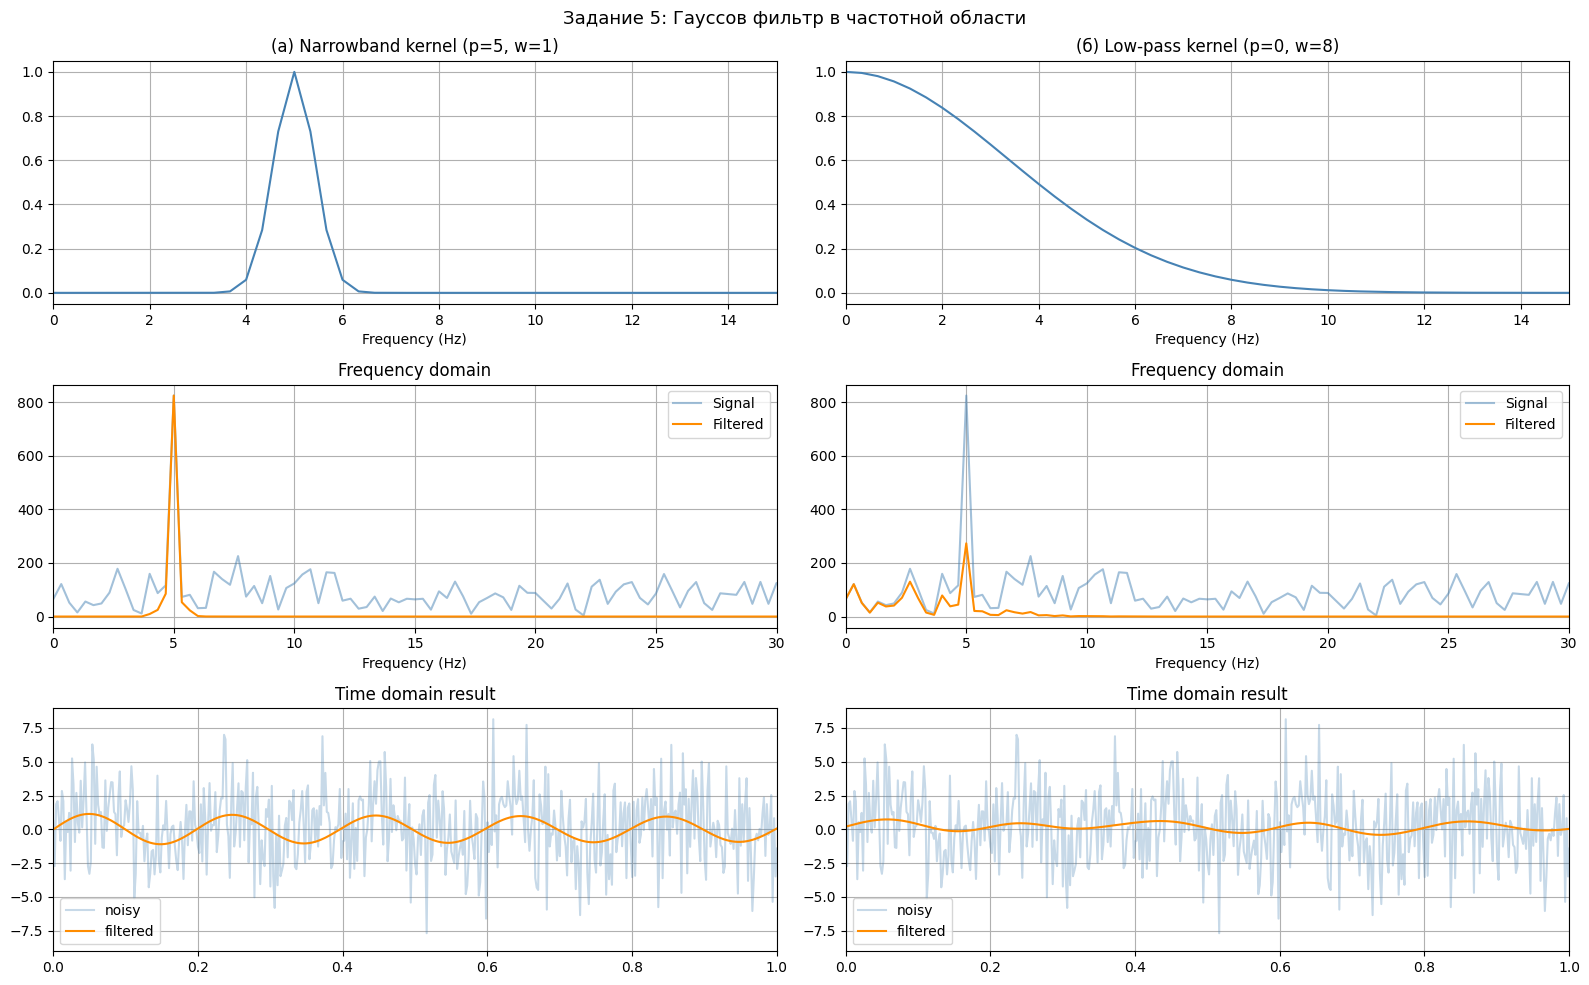

In [40]:
freqs5 = np.fft.fftfreq(len(t4), d=1/fs)

def gaussian_freq_kernel(freqs, p, w):
    """Гауссово ядро в частотной области. p — пиковая частота, w — FWHM."""
    s = w * (2 * np.pi - 1) / (4 * np.pi)
    return np.exp(-0.5 * ((freqs - p) / s)**2)

def apply_freq_filter(signal, kernel):
    """Умножение спектра сигнала на ядро → IFFT."""
    S = np.fft.fft(signal)
    return np.fft.ifft(S * kernel).real

# (а) узкополосный фильтр — p=5 Hz, w=1 Hz
kernel_narrow  = gaussian_freq_kernel(freqs5, p=5.0, w=1.0)
# симметрия для отрицательных частот
kernel_narrow += gaussian_freq_kernel(freqs5, p=-5.0, w=1.0)
filtered_narrow = apply_freq_filter(noisy, kernel_narrow)

# (б) ФНЧ — p=0, w=8 Hz
kernel_lp  = gaussian_freq_kernel(freqs5, p=0.0, w=8.0)
filtered_lp = apply_freq_filter(noisy, kernel_lp)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
fig.suptitle('Задание 5: Гауссов фильтр в частотной области', fontsize=13)

half = len(freqs5) // 2

# --- (а) узкополосный ---
axes[0, 0].plot(freqs5[:half], kernel_narrow[:half], color='steelblue')
axes[0, 0].set_title('(а) Narrowband kernel (p=5, w=1)')
axes[0, 0].set_xlabel('Frequency (Hz)')

axes[1, 0].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half],        color='steelblue', alpha=0.5, label='Signal')
axes[1, 0].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half] * kernel_narrow[:half], color='darkorange', label='Filtered')
axes[1, 0].set_title('Frequency domain')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].legend()

axes[2, 0].plot(t4, noisy,          color='steelblue', alpha=0.3, label='noisy')
axes[2, 0].plot(t4, filtered_narrow, color='darkorange', label='filtered')
axes[2, 0].set_title('Time domain result')
axes[2, 0].legend()

# --- (б) ФНЧ ---
axes[0, 1].plot(freqs5[:half], kernel_lp[:half], color='steelblue')
axes[0, 1].set_title('(б) Low-pass kernel (p=0, w=8)')
axes[0, 1].set_xlabel('Frequency (Hz)')

axes[1, 1].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half],       color='steelblue', alpha=0.5, label='Signal')
axes[1, 1].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half] * kernel_lp[:half], color='darkorange', label='Filtered')
axes[1, 1].set_title('Frequency domain')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].legend()

axes[2, 1].plot(t4, noisy,       color='steelblue', alpha=0.3, label='noisy')
axes[2, 1].plot(t4, filtered_lp, color='darkorange', label='filtered')
axes[2, 1].set_title('Time domain result')
axes[2, 1].legend()

axes[0, 0].set_xlim(0, 15)
axes[0, 1].set_xlim(0, 15)
axes[1, 0].set_xlim(0, 30)
axes[1, 1].set_xlim(0, 30)

axes[2, 0].set_xlim(0, 1)
axes[2, 1].set_xlim(0, 1)
plt.tight_layout()
plt.show()

## Задание 6
Полосовой фильтр с использованием окна Планка (Planck-taper window).

Применяем как полосовой фильтр в частотной области.

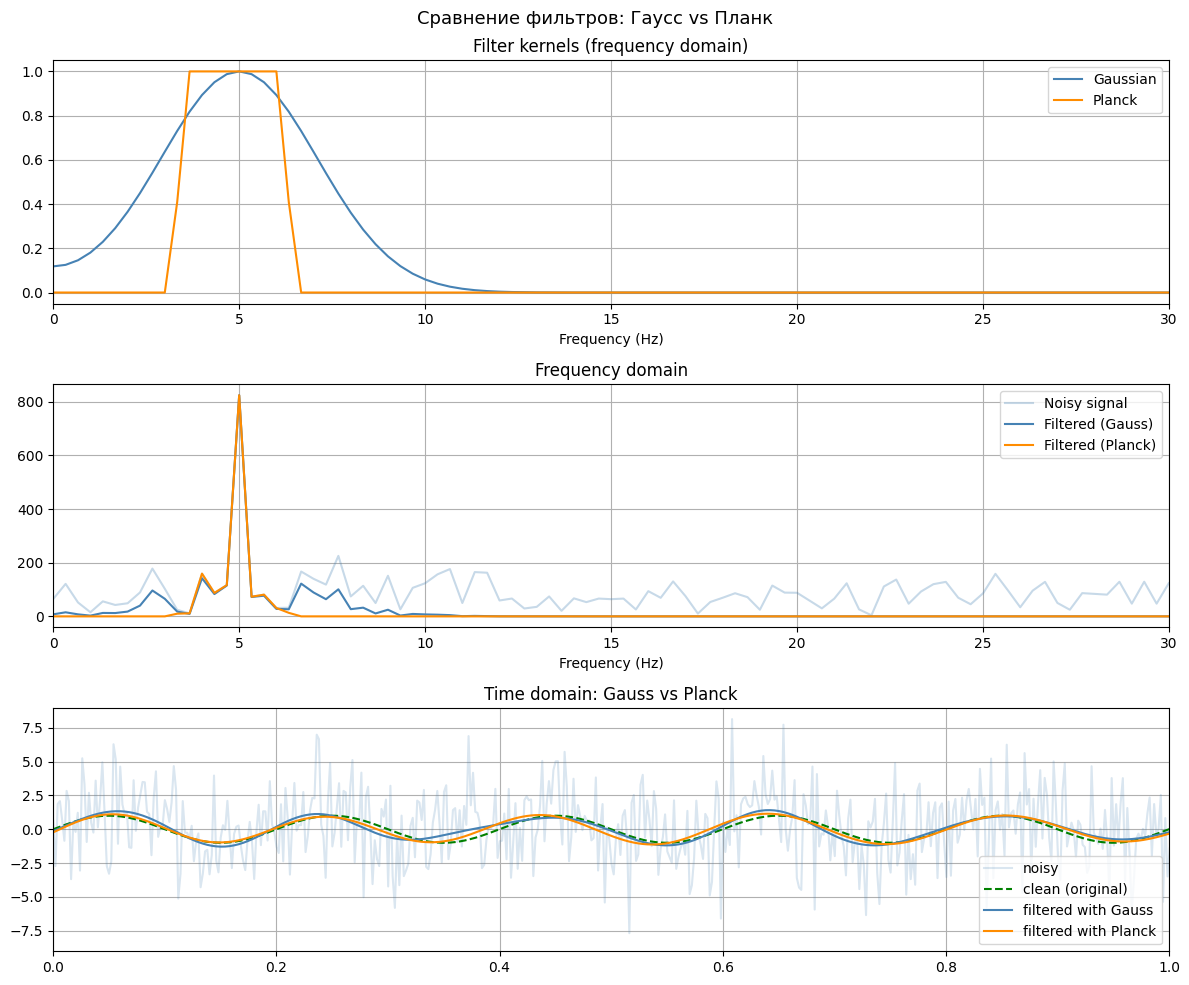

In [48]:
def planck_taper(N, eps=0.1):
    """Окно Планка длиной N с параметром eps."""
    w = np.ones(N)
    for t in range(1, N-1):
        if 0 < t < eps * (N - 1):
            zl = eps * (N-1) * (1/t + 1/(t - eps*(N-1)))
            w[t] = 1 / (np.exp(zl) + 1)
        elif (1-eps) * (N-1) < t < N-1:
            zr = eps * (N-1) * (1/(N-1-t) + 1/((1-eps)*(N-1) - t))
            w[t] = 1 / (np.exp(zr) + 1)
    w[0]    = 0.0
    w[N-1]  = 0.0
    return w


def bandpass_planck(sig, fs, f_low, f_high, eps=0.1):
    """Полосовой фильтр Планка: строим окно нужной длины по числу точек в полосе."""
    N      = len(sig)
    freqs  = np.fft.fftfreq(N, d=1/fs)
    df     = freqs[1] - freqs[0]                      # шаг по частоте
    n_band = int(round((f_high - f_low) / df))        # точек в полосе

    taper  = planck_taper(n_band, eps=eps)

    H = np.zeros(N)
    for i, f in enumerate(freqs):
        if f_low <= f <= f_high:
            idx = int(round((f - f_low) / df))
            if 0 <= idx < n_band:
                H[i] = taper[idx]
        elif -f_high <= f <= -f_low:
            idx = int(round((-f - f_low) / df))
            if 0 <= idx < n_band:
                H[i] = taper[idx]

    S = np.fft.fft(sig)
    return np.fft.ifft(S * H).real, H, freqs


filtered_planck, H_planck, freqs5 = bandpass_planck(noisy, fs, f_low=3.0, f_high=7.0, eps=0.2)

# гаусс узкополосный из задания 5
kernel_narrow  = gaussian_freq_kernel(freqs5, p=5.0, w=5.0)
kernel_narrow += gaussian_freq_kernel(freqs5, p=-5.0, w=5.0)
filtered_gauss = apply_freq_filter(noisy, kernel_narrow)

half = len(freqs5) // 2

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Сравнение фильтров: Гаусс vs Планк', fontsize=13)

# ядра
axes[0].plot(freqs5[:half], kernel_narrow[:half], color='steelblue',  label='Gaussian')
axes[0].plot(freqs5[:half], H_planck[:half],      color='darkorange', label='Planck')
axes[0].set_title('Filter kernels (frequency domain)')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_xlim(0, 30)
axes[0].legend()

# спектры
axes[1].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half],                          color='steelblue',  alpha=0.3, label='Noisy signal')
axes[1].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half] * kernel_narrow[:half],   color='steelblue',  label='Filtered (Gauss)')
axes[1].plot(freqs5[:half], np.abs(np.fft.fft(noisy))[:half] * H_planck[:half],        color='darkorange', label='Filtered (Planck)')
axes[1].set_title('Frequency domain')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_xlim(0, 30)
axes[1].legend()

# временная область
axes[2].plot(t4, noisy,          color='steelblue',  alpha=0.2, label='noisy')
axes[2].plot(t4, clean, color='green', linestyle='--', label='clean (original)')
axes[2].plot(t4, filtered_gauss, color='steelblue',  label='filtered with Gauss')
axes[2].plot(t4, filtered_planck, color='darkorange', label='filtered with Planck')
axes[2].set_title('Time domain: Gauss vs Planck')
axes[2].set_xlim(0, 1)
axes[2].legend()

plt.tight_layout()
plt.show()